In [1]:
# DMC toy model
# 1D Harmonic Oscillator

"""
Solve  H = -1/2 d^2/dx^2 + 1/2 x^2  in 1D and verify the eigenfunctions.

Two independent checks:
  (1) Diagonalize H as a finite-difference matrix -> eigenvalues should be n+1/2,
      eigenvectors should match the analytic Hermite functions (overlap ~ 1).
  (2) Direct: apply H to the *analytic* Hermite function and confirm
      H psi_n = (n+1/2) psi_n  (residual ~ 0).  This is the "is it really an
      eigenfunction" test, independent of the diagonalization.
"""

import numpy as np
from numpy.polynomial.hermite import hermval
from math import factorial, pi
import scipy.linalg as la

In [17]:
# numerical eigensolver
# ----------------------------------------------------------------------
# Grid.  L must be large enough that the wavefunctions are ~0 at the edges
# (Dirichlet box approximating the infinite domain); dx small for accuracy.
# ----------------------------------------------------------------------
L  = 10.0
N  = 1000
x  = np.linspace(-L, L, N)
dx = x[1] - x[0]

# ----------------------------------------------------------------------
# H as a symmetric tridiagonal matrix.
#   kinetic -1/2 d^2/dx^2  via the 3-point stencil
#        f'' -> (f_{i+1} - 2 f_i + f_{i-1}) / dx^2
#   so   -1/2 f''  has  diagonal +1/dx^2,  off-diagonal -1/(2 dx^2)
#   plus the potential 1/2 x^2 on the diagonal.
# ----------------------------------------------------------------------
main = 1.0 / dx**2 + 0.5 * x**2          # kinetic diag + potential
off  = -0.5 / dx**2 * np.ones(N - 1)     # kinetic off-diagonal

E, V = la.eigh_tridiagonal(main, off)    # ascending eigenvalues, orthonormal cols

# discrete eigenvectors satisfy sum(v^2)=1; continuum norm needs /sqrt(dx)
psi_num = V / np.sqrt(dx)

# ----------------------------------------------------------------------
# Fix the arbitrary overall sign so each eigenfunction approaches 0 from
# ABOVE as x -> +inf (positive far-right tail).  We can't use the literal
# last grid point: out there the amplitude has decayed below roundoff noise,
# so its sign is meaningless.  Instead read the sign at the rightmost point
# whose amplitude is still safely above noise (1e-6 of the column's peak).
# ----------------------------------------------------------------------
thresh  = 1e-6 * np.abs(psi_num).max(axis=0)     # per-column noise floor
above   = np.abs(psi_num) > thresh               # (N, ncols) boolean
idx     = N - 1 - np.argmax(above[::-1], axis=0) # rightmost "above-noise" row per column
cols    = np.arange(psi_num.shape[1])
psi_num = psi_num * np.sign(psi_num[idx, cols])  # multiply each column by ±1

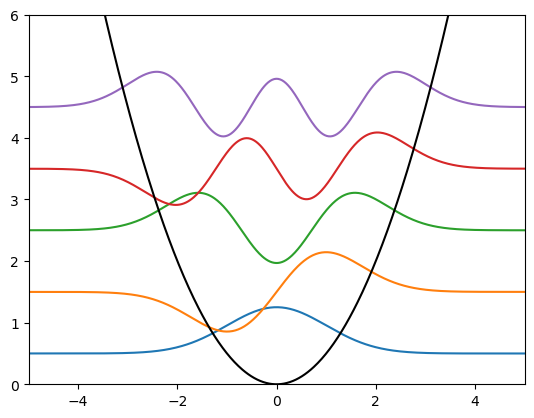

In [19]:
from matplotlib import pyplot as plt

plt.plot(x, psi_num[:,:5] + E[:5])
plt.plot(x, 0.5*x**2, 'k')
plt.ylim(0, 6)
plt.xlim(-5, 5)
plt.show()

In [20]:
# ----------------------------------------------------------------------
# Analytic eigenfunction:  psi_n = (2^n n! sqrt(pi))^{-1/2} H_n(x) e^{-x^2/2}
# ----------------------------------------------------------------------
def hermite_function(n, x):
    c = np.zeros(n + 1); c[n] = 1.0
    Hn = hermval(x, c) # physicists' Hermite H_n
    norm = (2.0**n * factorial(n) * np.sqrt(pi)) ** -0.5
    return norm * Hn * np.exp(-x**2 / 2)

# ----------------------------------------------------------------------
# Apply H to an arbitrary array (same finite-difference operator).
# ----------------------------------------------------------------------
def apply_H(psi, x, dx):
    lap = np.empty_like(psi)
    lap[1:-1] = (psi[2:] - 2*psi[1:-1] + psi[:-2]) / dx**2
    lap[0]    = (psi[1]  - 2*psi[0]) / dx**2          # psi=0 outside (Dirichlet)
    lap[-1]   = (psi[-2] - 2*psi[-1]) / dx**2
    return -0.5 * lap + 0.5 * x**2 * psi

# ======================================================================
# CHECK 1 — eigenvalues and eigenvector overlaps
# ======================================================================
print("CHECK 1:  diagonalized H vs analytic\n")
print(" n   E_numeric    E_exact   |overlap with Hermite|")
for n in range(6):
    psi_a = hermite_function(n, x)
    overlap = np.sum(psi_num[:, n] * psi_a) * dx     # sign-free magnitude below
    print(f" {n}   {E[n]:.6f}   {n+0.5:.6f}        {abs(overlap):.6f}")

# ======================================================================
# CHECK 2 — is the ANALYTIC function really an eigenfunction?
#   report max |H psi_n - (n+1/2) psi_n| in the bulk |x|<4
# ======================================================================
print("\nCHECK 2:  apply H to analytic psi_n, residual H psi - E psi\n")
bulk = np.abs(x) < 4.0
print(" n   max|H psi - (n+1/2) psi|   (should be ~ dx^2 small)")
for n in range(6):
    psi_a = hermite_function(n, x)
    res = apply_H(psi_a, x, dx) - (n + 0.5) * psi_a
    print(f" {n}   {np.max(np.abs(res[bulk])):.3e}")

print(f"\n(dx = {dx:.4f},  dx^2 = {dx**2:.2e})")

CHECK 1:  diagonalized H vs analytic

 n   E_numeric    E_exact   |overlap with Hermite|
 0   0.499987   0.500000        1.000000
 1   1.499937   1.500000        1.000000
 2   2.499837   2.500000        1.000000
 3   3.499687   3.500000        1.000000
 4   4.499486   4.500000        1.000000
 5   5.499236   5.500000        1.000000

CHECK 2:  apply H to analytic psi_n, residual H psi - E psi

 n   max|H psi - (n+1/2) psi|   (should be ~ dx^2 small)
 0   3.762e-05
 1   1.026e-04
 2   2.394e-04
 3   3.918e-04
 4   6.371e-04
 5   8.715e-04

(dx = 0.0200,  dx^2 = 4.01e-04)


In [21]:
# Deterministic Imaginary-Time Propagation
"""
Imaginary-time propagation of an initial guess on a real-space grid, using the
matrix exponential of the finite-difference Hamiltonian.

    phi(tau) = exp(-H tau) phi_0   ->   ground state as tau -> infinity
    (every eigencomponent decays as exp(-E_n tau); the slowest survivor is E_0)

Note: U = expm(-H dtau) is the EXACT propagator of the *discretized* H, so there
is NO time-step (Trotter) error here -- unlike split-operator or DMC.  The only
error is the spatial finite-difference discretization (~ dx^2).
"""

import numpy as np
import scipy.linalg as la

# ---- grid (same operator as the eigen-solver) ----
L  = 10.0
N  = 1000
x  = np.linspace(-L, L, N)
dx = x[1] - x[0]

# ---- H as a dense finite-difference matrix ----
main = 1.0 / dx**2 + 0.5 * x**2
off  = -0.5 / dx**2 * np.ones(N - 1)
H    = np.diag(main) + np.diag(off, 1) + np.diag(off, -1)

# ---- short-time propagator, computed ONCE and reused ----
dtau = 0.05
U    = la.expm(-dtau * H)            # exact exp of the discretized H

# ---- initial guess: an OFF-CENTER Gaussian (deliberately not the answer,
#      so it carries excited-state contamination to be filtered out) ----
phi  = np.exp(-(x - 1.5)**2)
phi /= np.sqrt(np.sum(phi**2) * dx)  # L2-normalize on the grid

def energy(p):
    """Variational energy estimator <p|H|p>/<p|p>."""
    return (p @ (H @ p)) / (p @ p)   # dx cancels in the ratio

# ---- exact ground state for reference ----
psi0 = np.exp(-x**2 / 2)
psi0 /= np.sqrt(np.sum(psi0**2) * dx)

In [22]:
"""
Visualize imaginary-time relaxation:
  (left)  the wavefunction phi(x,tau) morphing from the initial guess into the
          ground state e^{-x^2/2}
  (right) the energy E(tau) decaying to the exact ground-state energy 1/2
"""

import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

# ---- grid + Hamiltonian (same operator as before) ----
L  = 10.0
N  = 1000
x  = np.linspace(-L, L, N)
dx = x[1] - x[0]

main = 1.0 / dx**2 + 0.5 * x**2
off  = -0.5 / dx**2 * np.ones(N - 1)
H    = np.diag(main) + np.diag(off, 1) + np.diag(off, -1)

dtau = 0.05
U    = la.expm(-dtau * H)

def energy(p):
    return (p @ (H @ p)) / (p @ p)

# ---- exact ground state for reference ----
psi0 = np.exp(-x**2 / 2)
psi0 /= np.sqrt(np.sum(psi0**2) * dx)

In [25]:
# ---- initial guess: off-center Gaussian (carries excited-state contamination) ----
phi  = -np.sin(x) * np.exp(-(x+3)**2)
phi /= np.sqrt(np.sum(phi**2) * dx)

# ---- propagate, recording E(tau) and snapshots at selected tau ----
nsteps     = 200
#snap_taus  = [0.0, 0.25, 0.5, 1.0, 2.0, 4.0, 8.0]   # times to snapshot phi
snap_steps = 10 #{int(round(t / dtau)): t for t in snap_taus}

taus, Es, snapshots = [0.0], [energy(phi)], {0: phi.copy()}
print(" tau      E(tau)")
print(f"{0.0:5.2f}   {energy(phi):.6f}")
prev_lognorm = 0.0
for k in range(1, nsteps + 1):
    phi  = U @ phi
    phi /= np.sqrt(np.sum(phi**2) * dx)
    taus.append(k * dtau)
    Es.append(energy(phi))
    if k % snap_steps == 0:
        snapshots[k] = phi.copy()
        print(f"{k*dtau:5.2f}   {energy(phi):.6f}")

taus = np.array(taus); Es = np.array(Es)

 tau      E(tau)
 0.00   5.887516
 0.50   2.230334
 1.00   1.293968
 1.50   0.821099
 2.00   0.622423
 2.50   0.545632
 3.00   0.516862
 3.50   0.506207
 4.00   0.502277
 4.50   0.500830
 5.00   0.500297
 5.50   0.500102
 6.00   0.500029
 6.50   0.500003
 7.00   0.499993
 7.50   0.499990
 8.00   0.499988
 8.50   0.499988
 9.00   0.499988
 9.50   0.499988
10.00   0.499987


saved figure
final E = 0.499987   |<phi|psi0>| = 1.000000


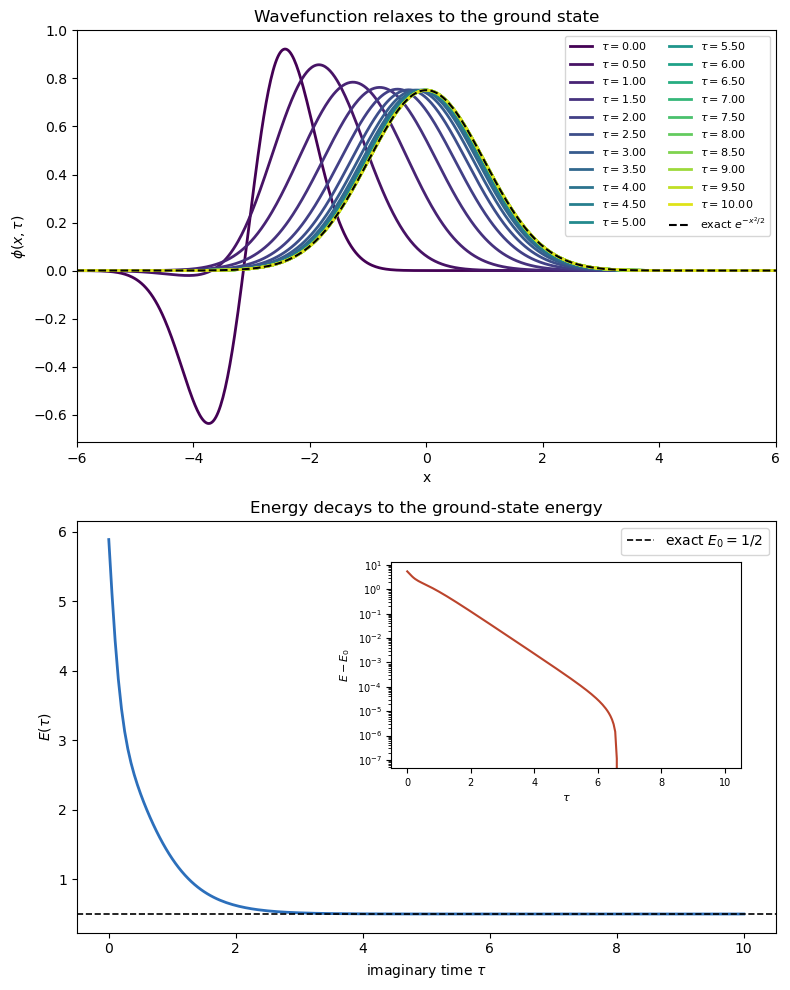

In [38]:
# ====================================================================
# PLOT
# ====================================================================
E0 = 0.5

fig, (axL, axR) = plt.subplots(2, 1, figsize=(8, 10))

# --- left: wavefunction snapshots, colored light->dark with increasing tau ---
cmap = plt.cm.viridis
keys = sorted(snapshots.keys())
for i, k in enumerate(keys):
    frac = i / (len(keys) - 1)
    axL.plot(x, snapshots[k], color=cmap(0.95 * frac),
             lw=2, label=fr"$\tau={k*dtau:.2f}$")
axL.plot(x, psi0, 'k--', lw=1.5, label=r"exact $e^{-x^2/2}$")
axL.set_xlim(-6, 6)
axL.set_xlabel("x"); axL.set_ylabel(r"$\phi(x,\tau)$")
axL.set_title("Wavefunction relaxes to the ground state")
axL.legend(fontsize=8, ncol=2)

# --- right: energy convergence ---
axR.plot(taus, Es, lw=2, color="#2c6fbb")
axR.axhline(E0, color="k", ls="--", lw=1.2, label=r"exact $E_0=1/2$")
axR.set_xlabel(r"imaginary time $\tau$"); axR.set_ylabel(r"$E(\tau)$")
axR.set_title("Energy decays to the ground-state energy")
axR.legend(fontsize=10)

# inset: log-scale of (E - E0) to expose the exponential approach
axins = axR.inset_axes([0.45, 0.40, 0.5, 0.5])
axins.semilogy(taus, Es - E0, color="#bb442c", lw=1.5)
axins.set_xlabel(r"$\tau$", fontsize=8)
axins.set_ylabel(r"$E-E_0$", fontsize=8)
axins.tick_params(labelsize=7)

plt.tight_layout()
print("saved figure")
print(f"final E = {Es[-1]:.6f}   |<phi|psi0>| = {abs(np.sum(phi*psi0)*dx):.6f}")

In [40]:
# Stochastic DMC
"""
Pure Diffusion Monte Carlo (NO importance sampling) for the 1D harmonic
oscillator  H = -1/2 d^2/dx^2 + 1/2 x^2.

This is the direct stochastic realization of the imaginary-time path integral:
each short step is  diffusion  x_i -> x_i + sqrt(dtau)*N(0,1)   [kinetic kernel]
followed by        branching   replicate/kill with weight exp(-dtau*(V-E_T)).
The walker population relaxes to phi_0(x) = e^{-x^2/2}, and E_T -> E_0 = 1/2.

Two energy estimators (both should give 0.5):
  * growth estimator  : time-average of the reference energy E_T
  * potential estimator: <V> over walkers.  Works because walkers sample phi_0
    (not phi_0^2), and  integral V phi_0 / integral phi_0 = E_0  -- the kinetic
    part integrates to a vanishing boundary term, so <V> alone equals E_0.
    (For phi_0 = e^{-x^2/2} the walkers are distributed as N(0,1), <x^2>=1,
     so <V> = 1/2 <x^2> = 1/2.)
"""

import numpy as np

rng = np.random.default_rng(1)

# ---- potential ----
def V(x):
    return 0.5 * x**2

# ---- parameters ----
N_target = 5000      # target walker population
dtau     = 0.01      # imaginary-time step (smaller -> less time-step bias)
nsteps   = 4000      # total steps
n_equil  = 1000      # discard these as equilibration
cap      = 3         # max copies per walker (guards against blow-up)

# ---- initialize walkers (spread out so nothing has to relax from a delta) ----
x   = rng.normal(0.0, 1.0, size=N_target)
E_T = np.mean(V(x))          # initial reference energy

growth_hist = []             # E_T trace
pot_hist    = []             # <V> per step
pop_hist    = []             # population trace

for step in range(nsteps):
    # 1) DIFFUSION: Gaussian step of variance dtau (the kinetic kernel)
    x = x + np.sqrt(dtau) * rng.standard_normal(x.size)

    # 2) BRANCHING: each walker spawns m copies, m = floor(w + u)
    w = np.exp(-dtau * (V(x) - E_T))
    m = np.floor(w + rng.random(x.size)).astype(int)
    np.clip(m, 0, cap, out=m)
    x = np.repeat(x, m)                       # kill (m=0), keep (1), duplicate (>=2)

    N = x.size
    if N == 0:                                # safety: extinction
        raise RuntimeError("population died out; reduce dtau or raise N_target")

    # 3) POPULATION CONTROL: nudge E_T to pull N back toward N_target.
    #    Negative feedback: if N grew, lower E_T (weaker branching), and vice versa.
    #    The gain alpha<1 softens the per-step swing in E_T (less growth-estimator noise).
    alpha = 0.1
    E_T = E_T + (alpha / dtau) * np.log(N_target / N)

    growth_hist.append(E_T)
    pot_hist.append(np.mean(V(x)))
    pop_hist.append(N)

# ---- energy estimates (average over the post-equilibration block) ----
growth = np.array(growth_hist[n_equil:])
pot    = np.array(pot_hist[n_equil:])

def stats(a):
    return a.mean(), a.std() / np.sqrt(a.size)   # mean, naive standard error

g_mean, g_err = stats(growth)
p_mean, p_err = stats(pot)

print(f"walkers (final)      : {x.size}")
print(f"exact E0             : 0.500000")
print(f"growth estimator     : {g_mean:.5f} +/- {g_err:.5f}")
print(f"potential estimator  : {p_mean:.5f} +/- {p_err:.5f}")
print(f"<x^2> over walkers   : {np.mean(x**2):.4f}   (exact 1.0; walkers ~ N(0,1))")

walkers (final)      : 5306
exact E0             : 0.500000
growth estimator     : 0.50246 +/- 0.03304
potential estimator  : 0.49960 +/- 0.00020
<x^2> over walkers   : 1.0104   (exact 1.0; walkers ~ N(0,1))


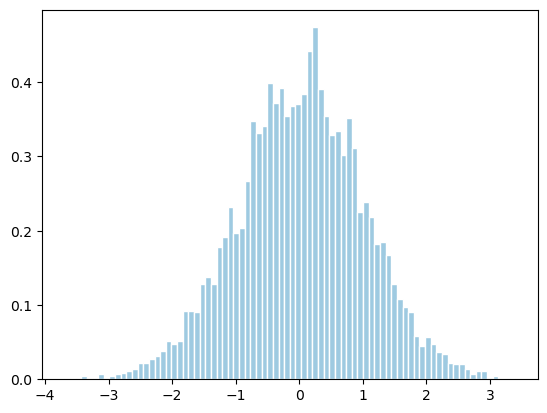

In [44]:
x   = rng.normal(0.0, 1.0, size=N_target)
plt.hist(x, bins=80, density=True, color="#9ecae1",
         edgecolor="white", label="DMC walkers")
plt.show()

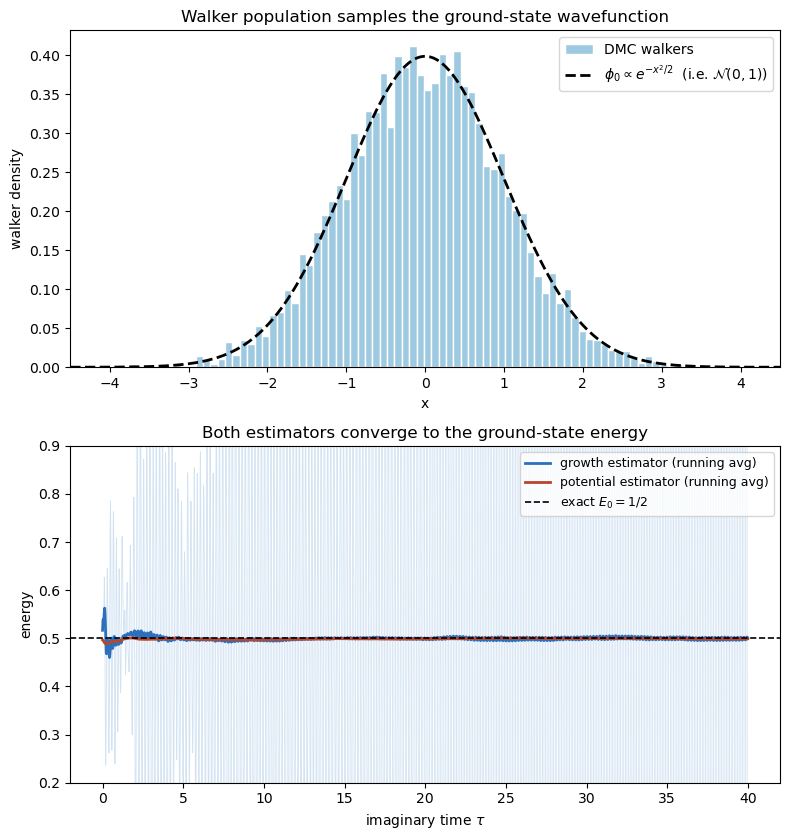

In [42]:
import numpy as np
import matplotlib.pyplot as plt

growth_hist = np.asarray(growth_hist)
pot_hist = np.asarray(pot_hist)
pop_hist = np.asarray(pop_hist)
dtau = 0.01
tau  = np.arange(len(growth_hist)) * dtau

fig, (axT, axB) = plt.subplots(2, 1, figsize=(8, 8.5))

# --- top: walker histogram vs ground-state distribution ---
# pure DMC samples phi_0 = e^{-x^2/2}; normalized as a density that is N(0,1).
axT.hist(x, bins=80, density=True, color="#9ecae1",
         edgecolor="white", label="DMC walkers")
xx = np.linspace(-4.5, 4.5, 400)
axT.plot(xx, np.exp(-xx**2 / 2) / np.sqrt(2*np.pi), "k--", lw=2,
         label=r"$\phi_0\propto e^{-x^2/2}$  (i.e. $\mathcal{N}(0,1)$)")
axT.set_xlim(-4.5, 4.5)
axT.set_xlabel("x"); axT.set_ylabel("walker density")
axT.set_title("Walker population samples the ground-state wavefunction")
axT.legend()

# --- bottom: energy convergence (running averages of both estimators) ---
def running_mean(a):
    return np.cumsum(a) / np.arange(1, len(a)+1)

axB.plot(tau, growth_hist, color="#c6dbef", lw=0.6, alpha=0.8)  # raw E_T
axB.plot(tau, running_mean(growth_hist), color="#2c6fbb", lw=2,
         label="growth estimator (running avg)")
axB.plot(tau, running_mean(pot_hist), color="#bb442c", lw=2,
         label="potential estimator (running avg)")
axB.axhline(0.5, color="k", ls="--", lw=1.2, label=r"exact $E_0=1/2$")
axB.set_ylim(0.2, 0.9)
axB.set_xlabel(r"imaginary time $\tau$"); axB.set_ylabel("energy")
axB.set_title("Both estimators converge to the ground-state energy")
axB.legend(fontsize=9)

plt.tight_layout()